German Traffic Sign Recognition Benchmark

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import kagglehub

In [2]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
train_dir = os.path.join(path, 'Train')

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.


In [3]:
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [4]:
full_data_train = datasets.ImageFolder(root=train_dir, transform=transform_train)
full_data_val   = datasets.ImageFolder(root=train_dir, transform=transform_test)

In [5]:
train_size = int(0.8 * len(full_data_train))
val_size   = len(full_data_train) - train_size

In [6]:
generator = torch.Generator().manual_seed(42)
train_data, _ = random_split(full_data_train, [train_size, val_size], generator=generator)
_, val_data   = random_split(full_data_val,   [train_size, val_size], generator=generator)

In [7]:
class_names = full_data_train.classes

In [8]:
train = DataLoader(train_data, batch_size=64, shuffle=True, pin_memory=True)
val   = DataLoader(val_data, batch_size=64, shuffle=False, pin_memory=True)

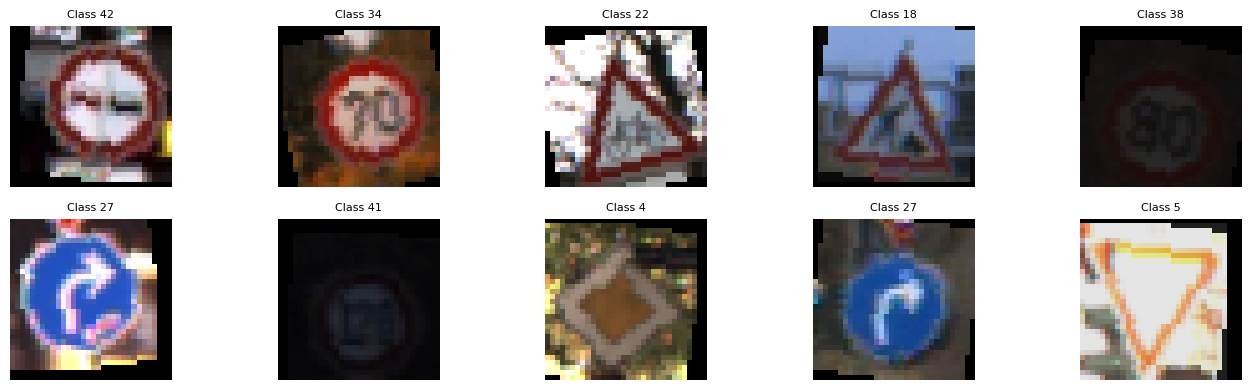

In [9]:
images, labels = next(iter(train))

plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = images[i].permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(img.clamp(0, 1))
    plt.title(f'Class {labels[i].item()}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_signs.png')
plt.show()

In [10]:
class TrafficSignClassifier(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [12]:
model_TrafficSignClassifier = TrafficSignClassifier(num_classes=len(class_names)).to(device)

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_TrafficSignClassifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [14]:
for epoch in range(30):
    model_TrafficSignClassifier.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model_TrafficSignClassifier(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    print(f'Эпоха {epoch + 1:02d} -- Потери: {round(total_loss, 2)}')

Эпоха 01 -- Потери: 1234.64
Эпоха 02 -- Потери: 776.8
Эпоха 03 -- Потери: 502.68
Эпоха 04 -- Потери: 338.58
Эпоха 05 -- Потери: 249.62
Эпоха 06 -- Потери: 194.02
Эпоха 07 -- Потери: 167.93
Эпоха 08 -- Потери: 138.48
Эпоха 09 -- Потери: 124.71
Эпоха 10 -- Потери: 120.59
Эпоха 11 -- Потери: 85.55
Эпоха 12 -- Потери: 75.61
Эпоха 13 -- Потери: 71.81
Эпоха 14 -- Потери: 67.48
Эпоха 15 -- Потери: 66.34
Эпоха 16 -- Потери: 61.19
Эпоха 17 -- Потери: 60.7
Эпоха 18 -- Потери: 58.37
Эпоха 19 -- Потери: 54.82
Эпоха 20 -- Потери: 50.86
Эпоха 21 -- Потери: 45.34
Эпоха 22 -- Потери: 44.25
Эпоха 23 -- Потери: 40.59
Эпоха 24 -- Потери: 40.25
Эпоха 25 -- Потери: 37.39
Эпоха 26 -- Потери: 35.46
Эпоха 27 -- Потери: 37.47
Эпоха 28 -- Потери: 36.65
Эпоха 29 -- Потери: 33.7
Эпоха 30 -- Потери: 34.06


In [15]:
model_TrafficSignClassifier.eval()
correct, total = 0, 0

with torch.no_grad():
    for x_batch, y_batch in val:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        prediction = model_TrafficSignClassifier(x_batch).argmax(dim=1)
        total += y_batch.size(0)
        correct += (prediction == y_batch).sum().item()

acc = correct * 100 / total
print(f'Точность на валидации: {round(acc, 2)}%')

Точность на валидации: 99.95%


In [17]:
def get_accuracy(data_loader):
    model_TrafficSignClassifier.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model_TrafficSignClassifier(x_batch)
            prediction = torch.argmax(y_pred, dim=1)
            total += y_batch.size(0)
            correct += (prediction == y_batch).sum().item()
    return round(correct * 100 / total, 2)

print(f'train score: {get_accuracy(train)}%')
print(f'val score: {get_accuracy(val)}%')

train score: 99.72%
val score: 99.95%


In [18]:
from google.colab import files

torch.save(class_names, 'labels_PDD_TrafficSignClassifier.pth')
torch.save(model_TrafficSignClassifier.state_dict(), 'model_PDD_TrafficSignClassifier.pth')

files.download('labels_PDD_TrafficSignClassifier.pth')
files.download('model_PDD_TrafficSignClassifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
gtsrb_classes = {
    0: 'Speed limit (20km/h)',
    1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)',
    5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    9: 'No passing',
    10: 'No passing for vehicles over 3.5 metric tons',
    11: 'Right-of-way at the next intersection',
    12: 'Priority road',
    13: 'Yield',
    14: 'Stop',
    15: 'No vehicles',
    16: 'Vehicles over 3.5 metric tons prohibited',
    17: 'No entry',
    18: 'General caution',
    19: 'Dangerous curve to the left',
    20: 'Dangerous curve to the right',
    21: 'Double curve',
    22: 'Bumpy road',
    23: 'Slippery road',
    24: 'Road narrows on the right',
    25: 'Road work',
    26: 'Traffic signals',
    27: 'Pedestrians',
    28: 'Children crossing',
    29: 'Bicycles crossing',
    30: 'Beware of ice/snow',
    31: 'Wild animals crossing',
    32: 'End of all speed and passing limits',
    33: 'Turn right ahead',
    34: 'Turn left ahead',
    35: 'Ahead only',
    36: 'Go straight or right',
    37: 'Go straight or left',
    38: 'Keep right',
    39: 'Keep left',
    40: 'Roundabout mandatory',
    41: 'End of no passing',
    42: 'End of no passing by vehicles over 3.5 metric tons'
}